In [2]:
%load_ext autoreload
%autoreload 2

In [63]:
import polars as pl
import polars.selectors as cs
from src.generate_semantic_views import AnalyticsRepository
from src.dashboard import DashboardRenderer

In [4]:
pl.Config.set_tbl_rows(1000)

polars.config.Config

### Initialize Analytics Repository to establish duckdb connection

In [5]:
analytics_repo =  AnalyticsRepository()

### Create and Execute View - DIMENSSION CONSUMER

In [6]:
analytics_repo.create_sql_views("create_consumer_view.sql")

  ✅  View created from create_consumer_view.sql file.


In [7]:
df = analytics_repo.select_dim_consumer()
print(df.head(10).collect())

shape: (10, 3)
┌──────────────┬──────────────┬───────────────────────────────┐
│ consumer_id  ┆ account_type ┆ address                       │
│ ---          ┆ ---          ┆ ---                           │
│ str          ┆ str          ┆ str                           │
╞══════════════╪══════════════╪═══════════════════════════════╡
│ CON-00000001 ┆ Residential  ┆ 6818 Hill St, Stonebridge     │
│ CON-00000002 ┆ Commercial   ┆ 399 Lake Dr, Clearwater       │
│ CON-00000003 ┆ Residential  ┆ 6673 Hill St, Lakeside        │
│ CON-00000004 ┆ Residential  ┆ 5824 Main St, Fairview        │
│ CON-00000005 ┆ Residential  ┆ 2225 Elm St, Meadowbrook      │
│ CON-00000006 ┆ Residential  ┆ 3005 Sunset Blvd, Greenfield  │
│ CON-00000007 ┆ Commercial   ┆ 3477 Sunset Blvd, Meadowbrook │
│ CON-00000008 ┆ Residential  ┆ 9427 Park Ave, Westport       │
│ CON-00000009 ┆ Commercial   ┆ 5024 Sunset Blvd, Clearwater  │
│ CON-00000010 ┆ Residential  ┆ 631 Hill St, Westport         │
└──────────────┴─────────

In [8]:
analytics_repo.create_sql_views('create_dim_utility_provider_view.sql')

  ✅  View created from create_dim_utility_provider_view.sql file.


In [9]:
df = analytics_repo.select_dim_utility_provider()
print(df.head(10).collect())

shape: (5, 3)
┌─────────────┬─────────────────────────┬─────────┐
│ provider_id ┆ name                    ┆ region  │
│ ---         ┆ ---                     ┆ ---     │
│ str         ┆ str                     ┆ str     │
╞═════════════╪═════════════════════════╪═════════╡
│ UP-001      ┆ Andes Power Co          ┆ North   │
│ UP-002      ┆ Pacifica Energy         ┆ South   │
│ UP-003      ┆ Northern Grid Utilities ┆ East    │
│ UP-004      ┆ Meridian Electric       ┆ West    │
│ UP-005      ┆ Southern Cross Power    ┆ Central │
└─────────────┴─────────────────────────┴─────────┘


### Create and Execute - DIMENSSION DATA MANAGEMENT SYSTEM

In [10]:
analytics_repo.create_sql_views('create_dim_data_mgmt_system_view.sql')

  ✅  View created from create_dim_data_mgmt_system_view.sql file.


In [11]:
df = analytics_repo.select_dim_data_mgmt_system()
print(df.head(10).collect())

shape: (5, 4)
┌───────────┬─────────────┬────────────────┬──────────────────┐
│ system_id ┆ provider_id ┆ storage_type   ┆ analytics_engine │
│ ---       ┆ ---         ┆ ---            ┆ ---              │
│ str       ┆ str         ┆ str            ┆ str              │
╞═══════════╪═════════════╪════════════════╪══════════════════╡
│ DMS-001   ┆ UP-005      ┆ Data Lake      ┆ DuckDB           │
│ DMS-002   ┆ UP-002      ┆ Data Lake      ┆ Spark            │
│ DMS-003   ┆ UP-004      ┆ Data Warehouse ┆ Presto           │
│ DMS-004   ┆ UP-001      ┆ Hybrid         ┆ Presto           │
│ DMS-005   ┆ UP-003      ┆ Data Lake      ┆ Presto           │
└───────────┴─────────────┴────────────────┴──────────────────┘


### Create and Execute View - DIMENSSION GENERATION DER

In [12]:
analytics_repo.create_sql_views('create_dim_generation_der_view.sql')

  ✅  View created from create_dim_generation_der_view.sql file.


In [13]:
df = analytics_repo.select_dim_generation_der()
print(df.head(100).collect())

shape: (60, 4)
┌─────────┬──────────────┬────────────────┬───────────────┐
│ der_id  ┆ der_type     ┆ capacity_value ┆ capacity_unit │
│ ---     ┆ ---          ┆ ---            ┆ ---           │
│ str     ┆ str          ┆ f64            ┆ str           │
╞═════════╪══════════════╪════════════════╪═══════════════╡
│ ES-0001 ┆ Lithium-Ion  ┆ 58825.7        ┆ kWh           │
│ ES-0002 ┆ Flow Battery ┆ 65334.8        ┆ kWh           │
│ ES-0003 ┆ Pumped Hydro ┆ 9360.0         ┆ kWh           │
│ ES-0004 ┆ Lithium-Ion  ┆ 42164.9        ┆ kWh           │
│ ES-0005 ┆ Pumped Hydro ┆ 5119.8         ┆ kWh           │
│ ES-0006 ┆ Flow Battery ┆ 49905.1        ┆ kWh           │
│ ES-0007 ┆ Flywheel     ┆ 33656.3        ┆ kWh           │
│ ES-0008 ┆ Pumped Hydro ┆ 15307.9        ┆ kWh           │
│ ES-0009 ┆ Pumped Hydro ┆ 11236.9        ┆ kWh           │
│ ES-0010 ┆ Lithium-Ion  ┆ 59176.8        ┆ kWh           │
│ ES-0011 ┆ Flow Battery ┆ 17888.7        ┆ kWh           │
│ ES-0012 ┆ Flywheel     

#### Create and Execute View - DIMENSSION METERING

In [14]:
analytics_repo.create_sql_views('create_dim_metering_view.sql')

  ✅  View created from create_dim_metering_view.sql file.


In [15]:
df = analytics_repo.select_dim_metering()
print(df.head(100).collect())

shape: (100, 9)
┌─────────┬────────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ hes_id  ┆ network_ty ┆ coverage_ ┆ dms_syste ┆ … ┆ dms_analy ┆ provider_ ┆ provider_ ┆ provider_ │
│ ---     ┆ pe         ┆ area      ┆ m_id      ┆   ┆ tics_engi ┆ id        ┆ name      ┆ region    │
│ str     ┆ ---        ┆ ---       ┆ ---       ┆   ┆ ne        ┆ ---       ┆ ---       ┆ ---       │
│         ┆ str        ┆ str       ┆ str       ┆   ┆ ---       ┆ str       ┆ str       ┆ str       │
│         ┆            ┆           ┆           ┆   ┆ str       ┆           ┆           ┆           │
╞═════════╪════════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ HES-001 ┆ RF-Mesh    ┆ Zone 71   ┆ DMS-004   ┆ … ┆ Presto    ┆ UP-001    ┆ Andes     ┆ North     │
│         ┆            ┆           ┆           ┆   ┆           ┆           ┆ Power Co  ┆           │
│ HES-002 ┆ RF-Mesh    ┆ Zone 55   ┆ DMS-003   ┆ … ┆ Presto    ┆ UP-004    

### Create and Execute View - DIMENSSION GENERATION BULK

In [16]:
analytics_repo.create_sql_views('create_dim_generation_bulk_view.sql')

  ✅  View created from create_dim_generation_bulk_view.sql file.


In [17]:
df = analytics_repo.select_dim_generation_bulk()
print(df.head(10).collect())

shape: (10, 6)
┌──────────┬─────────┬─────────────┬─────────────┬─────────────────────────┬─────────────────┐
│ plant_id ┆ type    ┆ capacity_mw ┆ provider_id ┆ provider_name           ┆ provider_region │
│ ---      ┆ ---     ┆ ---         ┆ ---         ┆ ---                     ┆ ---             │
│ str      ┆ str     ┆ f64         ┆ str         ┆ str                     ┆ str             │
╞══════════╪═════════╪═════════════╪═════════════╪═════════════════════════╪═════════════════╡
│ PP-0001  ┆ Coal    ┆ 332.2       ┆ UP-001      ┆ Andes Power Co          ┆ North           │
│ PP-0002  ┆ Gas     ┆ 726.7       ┆ UP-004      ┆ Meridian Electric       ┆ West            │
│ PP-0003  ┆ Diesel  ┆ 113.5       ┆ UP-004      ┆ Meridian Electric       ┆ West            │
│ PP-0004  ┆ Gas     ┆ 273.7       ┆ UP-003      ┆ Northern Grid Utilities ┆ East            │
│ PP-0005  ┆ Gas     ┆ 1040.4      ┆ UP-003      ┆ Northern Grid Utilities ┆ East            │
│ PP-0006  ┆ Gas     ┆ 1129.9      

### Create and Execute View - DIMENSSION OPERATION GRID

In [18]:
analytics_repo.create_sql_views('create_dim_operation_grid_view.sql')

  ✅  View created from create_dim_operation_grid_view.sql file.


In [19]:
df = analytics_repo.select_dim_operation_grid()
print(df.head(100).collect())

shape: (100, 15)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ substatio ┆ substatio ┆ location  ┆ voltage_k ┆ … ┆ provider_ ┆ source_as ┆ power_tra ┆ distribu │
│ n_id      ┆ n_type    ┆ ---       ┆ v         ┆   ┆ region    ┆ set_type  ┆ nsformer_ ┆ tion_net │
│ ---       ┆ ---       ┆ str       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ count     ┆ work_cou │
│ str       ┆ str       ┆           ┆ f64       ┆   ┆ str       ┆ str       ┆ ---       ┆ nt       │
│           ┆           ┆           ┆           ┆   ┆           ┆           ┆ i64       ┆ ---      │
│           ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆ i64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ SUB-0131  ┆ Step-up   ┆ District  ┆ 34.5      ┆ … ┆ North     ┆ Coal      ┆ 4         ┆ 3        │
│           ┆           ┆ 113       ┆           ┆   ┆           ┆         

### Create and Execute View - FACT SMART METERS

In [20]:
analytics_repo.create_sql_views('create_fact_smart_meters_view.sql')

  ✅  View created from create_fact_smart_meters_view.sql file.


In [21]:
df = analytics_repo.select_fact_smart_meters()
print(df.head(100).collect())

shape: (100, 17)
┌────────────┬───────────┬───────────┬───────────┬───┬───────────┬─────────┬───────────┬───────────┐
│ meter_id   ┆ install_d ┆ reading_d ┆ comm_prot ┆ … ┆ grid_prov ┆ hes_id  ┆ hes_netwo ┆ metering_ │
│ ---        ┆ ate       ┆ ate       ┆ ocol      ┆   ┆ ider_name ┆ ---     ┆ rk_type   ┆ provider_ │
│ str        ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ str     ┆ ---       ┆ name      │
│            ┆ str       ┆ str       ┆ str       ┆   ┆ str       ┆         ┆ str       ┆ ---       │
│            ┆           ┆           ┆           ┆   ┆           ┆         ┆           ┆ str       │
╞════════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═════════╪═══════════╪═══════════╡
│ MTR-010228 ┆ 2022-09-2 ┆ 2026-07-2 ┆ PLC       ┆ … ┆ Northern  ┆ HES-175 ┆ RF-Mesh   ┆ Pacifica  │
│ 80         ┆ 8         ┆ 7         ┆           ┆   ┆ Grid      ┆         ┆           ┆ Energy    │
│            ┆           ┆           ┆           ┆   ┆ Utilities ┆        

### Create and Execute View - FACT ASSETS CAPACITY

In [22]:
analytics_repo.create_sql_views('create_fact_assets_capacity_view.sql')

  ✅  View created from create_fact_assets_capacity_view.sql file.


In [28]:
df = analytics_repo.select_fact_assets_capacity()
print(df.head(200).collect())

ConnectionException: Connection Error: Connection already closed!

In [24]:
power_plants_df = df.filter(pl.col("domain") == "Power Plants").collect()
print(power_plants_df)

shape: (25, 5)
┌──────────┬─────────────┬──────────────┬────────┬──────┐
│ asset_id ┆ asset_type  ┆ domain       ┆ value  ┆ unit │
│ ---      ┆ ---         ┆ ---          ┆ ---    ┆ ---  │
│ str      ┆ str         ┆ str          ┆ f64    ┆ str  │
╞══════════╪═════════════╪══════════════╪════════╪══════╡
│ PP-0001  ┆ POWER_PLANT ┆ Power Plants ┆ 332.2  ┆ mw   │
│ PP-0002  ┆ POWER_PLANT ┆ Power Plants ┆ 726.7  ┆ mw   │
│ PP-0003  ┆ POWER_PLANT ┆ Power Plants ┆ 113.5  ┆ mw   │
│ PP-0004  ┆ POWER_PLANT ┆ Power Plants ┆ 273.7  ┆ mw   │
│ PP-0005  ┆ POWER_PLANT ┆ Power Plants ┆ 1040.4 ┆ mw   │
│ PP-0006  ┆ POWER_PLANT ┆ Power Plants ┆ 1129.9 ┆ mw   │
│ PP-0007  ┆ POWER_PLANT ┆ Power Plants ┆ 1452.9 ┆ mw   │
│ PP-0008  ┆ POWER_PLANT ┆ Power Plants ┆ 522.4  ┆ mw   │
│ PP-0009  ┆ POWER_PLANT ┆ Power Plants ┆ 587.2  ┆ mw   │
│ PP-0010  ┆ POWER_PLANT ┆ Power Plants ┆ 730.9  ┆ mw   │
│ PP-0011  ┆ POWER_PLANT ┆ Power Plants ┆ 324.7  ┆ mw   │
│ PP-0012  ┆ POWER_PLANT ┆ Power Plants ┆ 238.4  ┆ mw   │

### -- Materialized SQL Semantic Views to parquet

In [26]:
analytics_repo.materialize_views_to_parquet()

Starting materialization of semantic layer to Parquet...
  [EXPORTED] dim_utility_provider -> /workspace/data/4_analytics/dim_utility_provider.parquet
  [EXPORTED] dim_consumer -> /workspace/data/4_analytics/dim_consumer.parquet
  [EXPORTED] dim_data_mgmt_system -> /workspace/data/4_analytics/dim_data_mgmt_system.parquet
  [EXPORTED] dim_der -> /workspace/data/4_analytics/dim_der.parquet
  [EXPORTED] dim_generation_bulk -> /workspace/data/4_analytics/dim_generation_bulk.parquet
  [EXPORTED] dim_power_transformer -> /workspace/data/4_analytics/dim_power_transformer.parquet
  [EXPORTED] dim_distribution_transformer -> /workspace/data/4_analytics/dim_distribution_transformer.parquet
  [EXPORTED] dim_distribution_network -> /workspace/data/4_analytics/dim_distribution_network.parquet
  [EXPORTED] dim_metering -> /workspace/data/4_analytics/dim_metering.parquet
  [EXPORTED] dim_operation_grid -> /workspace/data/4_analytics/dim_operation_grid.parquet
  [EXPORTED] fact_assets_capacity -> /wor

### - Close Duckdb Instance.

In [27]:
analytics_repo.close_duckdb_connection()

### - Scan Analytics Layer

In [48]:
layers = analytics_repo.scan_analytics_layer()

In [49]:
print(layers['capacity'].head(20).collect())
print(layers['grid'].head(20).collect())
print(layers['meters'].head(20).collect())

shape: (20, 5)
┌──────────┬──────────────┬────────────────┬─────────┬──────┐
│ asset_id ┆ asset_type   ┆ domain         ┆ value   ┆ unit │
│ ---      ┆ ---          ┆ ---            ┆ ---     ┆ ---  │
│ str      ┆ str          ┆ str            ┆ f64     ┆ str  │
╞══════════╪══════════════╪════════════════╪═════════╪══════╡
│ ES-0001  ┆ Lithium-Ion  ┆ Generation DER ┆ 58825.7 ┆ kWh  │
│ ES-0002  ┆ Flow Battery ┆ Generation DER ┆ 65334.8 ┆ kWh  │
│ ES-0003  ┆ Pumped Hydro ┆ Generation DER ┆ 9360.0  ┆ kWh  │
│ ES-0004  ┆ Lithium-Ion  ┆ Generation DER ┆ 42164.9 ┆ kWh  │
│ ES-0005  ┆ Pumped Hydro ┆ Generation DER ┆ 5119.8  ┆ kWh  │
│ ES-0006  ┆ Flow Battery ┆ Generation DER ┆ 49905.1 ┆ kWh  │
│ ES-0007  ┆ Flywheel     ┆ Generation DER ┆ 33656.3 ┆ kWh  │
│ ES-0008  ┆ Pumped Hydro ┆ Generation DER ┆ 15307.9 ┆ kWh  │
│ ES-0009  ┆ Pumped Hydro ┆ Generation DER ┆ 11236.9 ┆ kWh  │
│ ES-0010  ┆ Lithium-Ion  ┆ Generation DER ┆ 59176.8 ┆ kWh  │
│ ES-0011  ┆ Flow Battery ┆ Generation DER ┆ 17888.7 ┆ 

### -  DASHBOARD 

In [64]:
analytics_dashboard = DashboardRenderer(layers['capacity'], layers['grid'], layers['meters'])

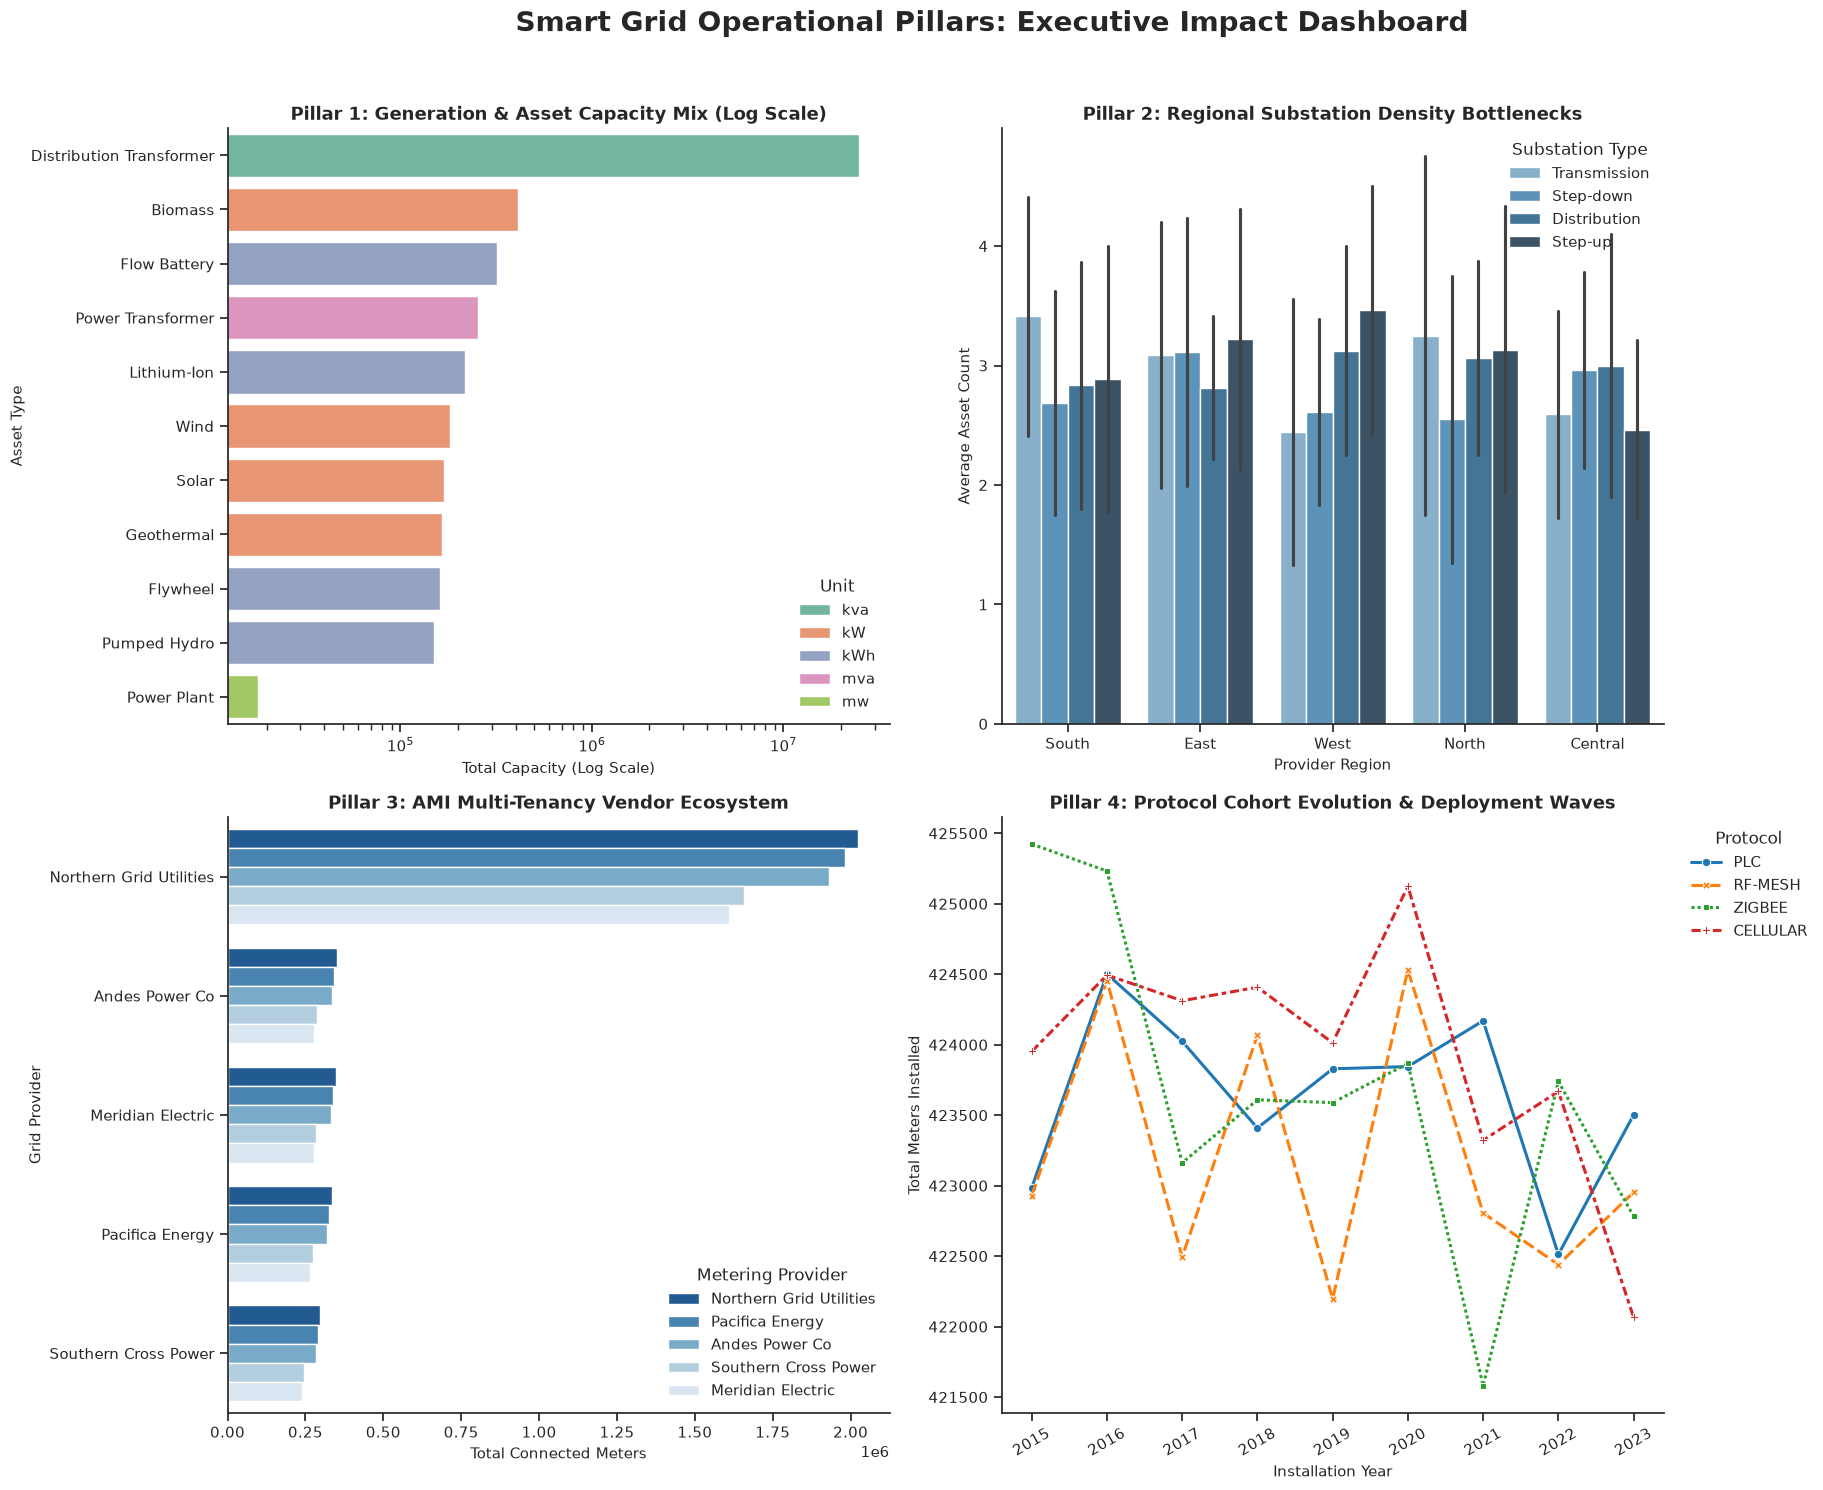

In [65]:
analytics_dashboard.render_executive_dashboard()